In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

In [144]:
# 64 subcarriers with 48 symbols, and cyclic prefix of 16, 10 frames
sbcarrs = 64
symbs = 48
frames = 10
prefix = 16

In [145]:
tx_bits = np.random.randint(0, 2, size=(frames, symbs, 2), dtype=int)
np.shape(tx_bits)
print(np.shape(tx_bits))
print(tx_bits)

(10, 48, 2)
[[[1 1]
  [1 1]
  [0 1]
  [1 1]
  [1 1]
  [0 0]
  [0 0]
  [1 0]
  [1 0]
  [1 0]
  [1 0]
  [0 1]
  [0 0]
  [0 1]
  [1 1]
  [0 1]
  [0 0]
  [1 1]
  [0 0]
  [1 1]
  [1 1]
  [1 0]
  [0 1]
  [1 0]
  [1 0]
  [1 0]
  [1 1]
  [0 0]
  [1 1]
  [0 1]
  [1 0]
  [0 0]
  [1 1]
  [0 1]
  [1 0]
  [0 1]
  [1 1]
  [0 1]
  [0 0]
  [0 1]
  [0 1]
  [1 1]
  [1 1]
  [0 1]
  [0 1]
  [1 0]
  [1 0]
  [0 1]]

 [[0 1]
  [1 1]
  [0 0]
  [1 1]
  [0 1]
  [1 0]
  [1 0]
  [0 0]
  [0 1]
  [1 0]
  [1 1]
  [0 1]
  [0 1]
  [1 1]
  [0 0]
  [1 1]
  [0 1]
  [1 1]
  [1 0]
  [1 1]
  [0 1]
  [1 1]
  [1 0]
  [0 0]
  [0 0]
  [1 0]
  [0 1]
  [0 0]
  [0 0]
  [0 0]
  [0 0]
  [1 1]
  [0 1]
  [1 1]
  [0 1]
  [0 0]
  [1 0]
  [0 1]
  [0 0]
  [1 0]
  [1 1]
  [1 1]
  [1 1]
  [1 0]
  [1 1]
  [0 1]
  [1 1]
  [0 0]]

 [[1 0]
  [0 0]
  [1 0]
  [1 1]
  [0 1]
  [1 0]
  [1 0]
  [0 0]
  [0 1]
  [0 0]
  [0 1]
  [1 0]
  [1 0]
  [1 1]
  [1 0]
  [0 0]
  [1 0]
  [1 1]
  [1 0]
  [1 1]
  [1 0]
  [0 1]
  [0 0]
  [0 0]
  [1 0]
  [1 1]
  [0 0]


In [217]:
# qpsk = tx_bits[:, :, 0] + 1j*tx_bits[:, :, 1]
real = 1 - 2 * tx_bits[:, :, 0]
imag = 1 - 2 * tx_bits[:, :, 1]
qpsk = (real + 1j*imag) / np.sqrt(2)
np.shape(qpsk)

(10, 48)

In [218]:
# tx_ofdm = np.fft.ifft(qpsk)
subcarriers = np.zeros((frames, sbcarrs), dtype=complex)
subcarriers[:, 1:1+symbs] = qpsk
tx_ofdm = np.fft.ifft(subcarriers)
# np.fft.fft(tx_ofdm)
np.shape(tx_ofdm)

(10, 64)

In [219]:
# Cyclical Prefix
cyclic_prefix = tx_ofdm[:, -prefix:]
print(np.shape(cyclic_prefix))
extended = np.zeros((10, sbcarrs+prefix), dtype=complex)
for i in range(0, frames):
    extended[i] = np.concatenate([cyclic_prefix[i], tx_ofdm[i]], axis=0)
print(np.shape(extended))

(10, 16)
(10, 80)


In [220]:
# Adding preamble for Frame Synchronization
short_symbol = np.array([
    0.046 + 0.046j, -0.132 + 0.002j, -0.013 - 0.079j, 0.143 - 0.013j,
    0.092 + 0.000j,  0.143 - 0.013j, -0.013 - 0.079j, -0.132 + 0.002j,
    0.046 + 0.046j,  0.002 - 0.132j, -0.079 - 0.013j, -0.013 + 0.143j,
    0.000 + 0.092j,  -0.013 + 0.143j, -0.079 - 0.013j,  0.002 - 0.132j
]) * np.sqrt(13/6)
STS = np.tile(short_symbol, 10)

L = np.array([
        1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1,
        1, -1, 1, -1, 1, 1, 1, 1, 0, 1, -1, -1, 1, 1, -1, 1, -1, 1,
        -1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1
    ])

long_symbol = np.zeros(64, dtype=complex)
long_symbol[1:27] = L[-26:]
long_symbol[38:64] = L[:26]

long_seq = np.fft.ifft(long_symbol)
lts_prefix = 32
lts_cp = long_seq[-lts_prefix:]
lts_no_cp = np.tile(long_seq, 2)
LTS = np.concatenate((lts_cp, lts_no_cp))

print(np.shape(LTS))

preamble = np.concatenate((STS, LTS), axis=None)
print(np.shape(preamble))
print(np.shape(extended.flatten()))
full = np.concatenate((preamble, extended.flatten()), axis=None)
print(np.shape(full))

(160,)
(320,)
(800,)
(1120,)


In [221]:
# Channel
channel_in = np.array(full)


# Two-Tap Channel
delay = 10 # must be shorter than prefix length
scale = 0.5
tx_with_delay = channel_in.copy()
tx_with_delay[delay:] += scale * channel_in[:-delay] *1
print(np.shape(tx_with_delay))
channel_out = np.array(tx_with_delay)


# Additive White Gaussian Noise parameters and Power calculation
mean = 0
x_I = np.real(tx_with_delay)
x_Q = np.real(tx_with_delay)
power = np.square(x_I) + np.square(x_Q)
P_signal = np.sum(power) / sbcarrs
print(P_signal)

(1120,)
0.3056744654133916


Coarse Offset:  2


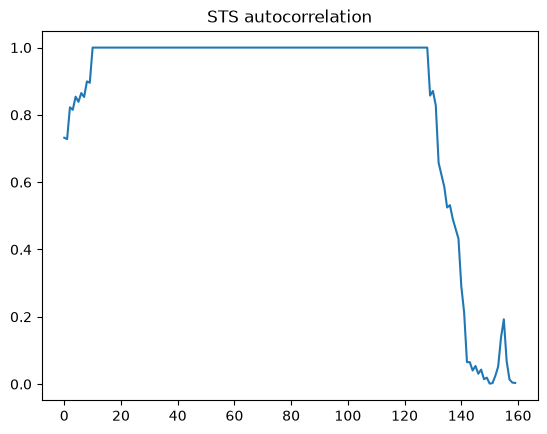

Data Start:  320


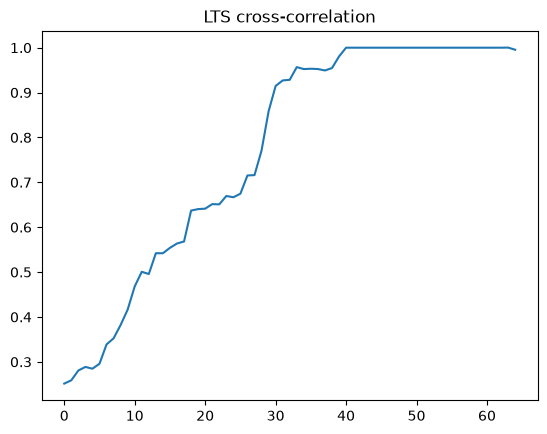

(800,)


In [222]:
# Detect preamble, remove, and receive

# Coarse Timing Autocorrelation for STS
D = len(short_symbol)
L = 16
product = channel_out[:-D] * np.conj(channel_out[D:])
norm = np.abs(channel_out[D:])**2

window = np.ones(L)
C = np.convolve(product, window, "valid")
E = np.convolve(norm, window, "valid")
M = np.abs(C)**2 / (E**2 + 1e-12)

correlated_indices = np.where(M > 0.8)[0]
if len(correlated_indices) == 0:
    coarse_offset = 0
else:
    coarse_offset = correlated_indices[0] # First index where threshold has been breached

print("Coarse Offset: ", coarse_offset)

plt.figure()
plt.title("STS autocorrelation")
plt.plot(M[:160])
plt.show()

# # Fine Timing Cross-Correlation for LTS
# width = 32

# # LTS prefix is 32 samples
# window_start = coarse_offset + 160 + 32 - width
# window_end = coarse_offset + 160 + 32 + width

# # Correlate with known time-domain long symbol
# C_lts = np.correlate(channel_out[window_start:window_end+64], np.conj(long_seq), "valid")

# print(np.max(C_lts))

# window_peak = np.argmax(np.abs(C_lts))
# lts_peak = window_start+window_peak
# data_start = lts_peak + 128
# print("Data Start: ", data_start)

# plt.figure()
# plt.title("LTS cross-correlation")
# plt.plot(C_lts)
# plt.show()


# Using LTS autocorrelation instead of Fine Timing Cross-Correlation
width = 32
start = coarse_offset + 160 + lts_prefix*0 - width
end = min(len(channel_out - 128), coarse_offset + 160 + lts_prefix*0 + width)

# 128 -> two 64-sample blocks for autocorrelation with delay 64
lts_segment = channel_out[start:end+128] 

D_lts = 64
L_lts = 64

p_lts = lts_segment[:-D_lts] * np.conj(lts_segment[D_lts:])
e_lts = np.abs(lts_segment[D_lts:])**2

window = np.ones(L_lts)
C_lts = np.convolve(p_lts, window, "valid")
E_lts = np.convolve(e_lts, window, "valid")
M_lts = np.abs(C_lts)**2 / (E_lts**2 + 1e-12)

threshold_lts = 0.8
ind = np.where(M_lts > threshold_lts)[0]
if len(ind) > 0:
    lts_start = start + ind[0] # first LTS symbol should breach the threshold
    data_start = lts_start + 160 + 1
else:
    data_start = 320
    print("WHAT")

print("Data Start: ", data_start)

plt.figure()
plt.title("LTS cross-correlation")
plt.plot(M_lts)
plt.show()

# Remove preamble and format data symbols
rx_sync = channel_out[data_start:]
print(np.shape(rx_sync))

In [228]:
# Remove Cyclic Prefix
unflattened = rx_sync.reshape(10, 80)
rx_ofdm = unflattened[:, prefix:]

# # Two-tap delay frequency response
# h_n = np.zeros((np.shape(rx_ofdm)), dtype=complex)
# h_n[:, 0] = 1
# h_n[:, delay] = scale
# H = np.fft.fft(h_n)


# Channel Estimation for unknown channel
# Calculate channel's frequency response based off of LTS
rx_LTS = channel_out[data_start-128:data_start-64]
Y_lts = np.fft.fft(rx_LTS)
# Since we know the actual LTS signal, we can divide
H = Y_lts / (long_symbol + 1e-12)






SNR_db = np.array([0, 2, 5, 10, 15, 20, 25, 30])
BER = np.zeros(np.shape(SNR_db))
print(BER)


# With channel's signal, iterate over decibel SNR values to produce received signal
for index in range(0, len(SNR_db)):

    # Add AWGN
    sigma = np.sqrt(P_signal / (2*( 10**(SNR_db[index]/10) )))
    print(sigma)
    awgn = np.random.normal(mean, sigma, (10, 64, 2))
    noise = awgn[:, :, 0] + 1j*awgn[:, :, 1]
    signal = rx_ofdm + noise*1

    # Transform back into frequency domain
    freq_signal = np.fft.fft(signal, axis=1)
    
    # Zero-Forcing Equalization for two-tap channel
    eq_signal = freq_signal / (H + 1e-12)

    # Capture symbols and convert back to bits
    freq_symbols = eq_signal[:, 1:1+symbs]
    # r = np.real(freq_symbols)
    # i = np.imag(freq_symbols)
    # bits = np.zeros((frames, symbs, 2), dtype=int)
    # bits[:, :, 0] = r.round().astype(int)
    # bits[:, :, 1] = i.round().astype(int)
    # bits = np.where(bits<0, 0, bits)
    # bits = np.where(bits>1, 1, bits)


    # Correct QPSK demapping:
    # i_samples = (freq_symbols.real > 0).astype(int)
    # q_samples = (freq_symbols.imag > 0).astype(int)
    # bits = np.zeros((frames, symbs, 2), dtype=int)
    # bits[:, :, 0] = i_samples
    # bits[:, :, 1] = q_samples
    real_bits = (np.real(freq_symbols) < 0).astype(int)   # negative real -> bit 1
    imag_bits = (np.imag(freq_symbols) < 0).astype(int)   # negative imag -> bit 1
    bits = np.zeros((frames, symbs, 2), dtype=int)
    bits[:, :, 0] = real_bits
    bits[:, :, 1] = imag_bits
    
    bit_errors = bits - tx_bits
    # BER[r] = np.count_nonzero(bit_errors) / bits.size
    num = np.count_nonzero(bit_errors) / bits.size
    BER[index] = num
print(BER)

[0. 0. 0. 0. 0. 0. 0. 0.]
0.3909440275879602
0.31053787930994525
0.21984398254906592
0.12362735648176572
0.06952077147373582
0.03909440275879602
0.021984398254906595
0.012362735648176571
[0.43020833 0.4        0.390625   0.31145833 0.1875     0.128125
 0.11041667 0.1125    ]


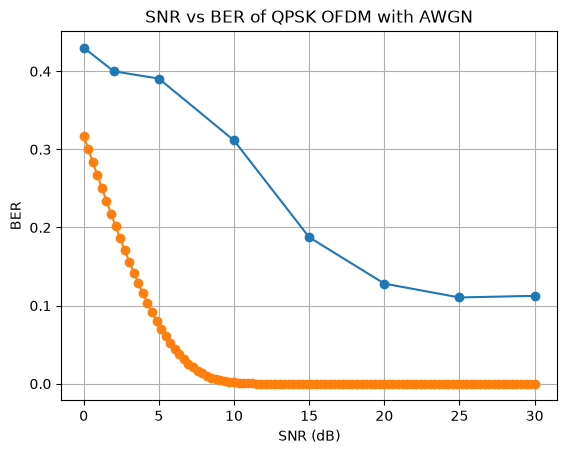

In [229]:
# Plotting

plt.figure()
plt.plot(SNR_db, BER, 'o-')
# plt.semilogy(SNR_db, BER, 'o-')

plt.title("SNR vs BER of QPSK OFDM with AWGN")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")


# Theoretical SNR vs BER to validate results
def BER_theoretical(SNR_decibel):
    SNR_linear = 10**(np.array(SNR_decibel, dtype=float)/10)
    return erfc(np.sqrt(SNR_linear/2))

snr_baseline = np.linspace(0, 30, 100) # Sweep from 0->30
ber_baseline = BER_theoretical(snr_baseline)
plt.plot(snr_baseline, ber_baseline, 'o-')


plt.grid(True)

plt.savefig("BER_AWGN_plot")
plt.show()